# Autonomous Credit Card Fraud Detection using Machine Learning

This notebook builds and evaluates fraud detection models on anonymized credit card transaction data.

Workflow overview:
1. Import libraries
2. Load and inspect dataset
3. Perform exploratory data analysis (EDA)
4. Preprocess data
5. Split data and handle imbalance
6. Train models
7. Evaluate models
8. Compare models
9. Save best model
10. Build prediction function
11. Summarize conclusions

## 1. Import Libraries

In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# TensorFlow / Keras for ANN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# Imbalanced-learn
from imblearn.over_sampling import SMOTE

# Model saving
import joblib

# Plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


## 2. Load Dataset

In [2]:
# Update this path only if your file is in a different location

df = pd.read_csv("C:/Users/ruthv/OneDrive/Desktop/credit card/creditcard.csv.zip")

print(f"Dataset shape: {df.shape}")
print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset shape: (284807, 31)

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. Data Exploration (EDA)

We inspect missing values, class imbalance, feature correlations, and transaction amount distribution.

In [3]:
# Check missing values
null_counts = df.isnull().sum()
print("Null values by column:")
print(null_counts[null_counts > 0])

if null_counts.sum() == 0:
    print("No missing values found.")

Null values by column:
Series([], dtype: int64)
No missing values found.


In [4]:
# Class distribution
class_counts = df['Class'].value_counts()
class_ratio = df['Class'].value_counts(normalize=True) * 100

print("Class counts:")
print(class_counts)
print("\nClass percentage (%):")
print(class_ratio.round(4))

Class counts:
Class
0    284315
1       492
Name: count, dtype: int64

Class percentage (%):
Class
0    99.8273
1     0.1727
Name: proportion, dtype: float64


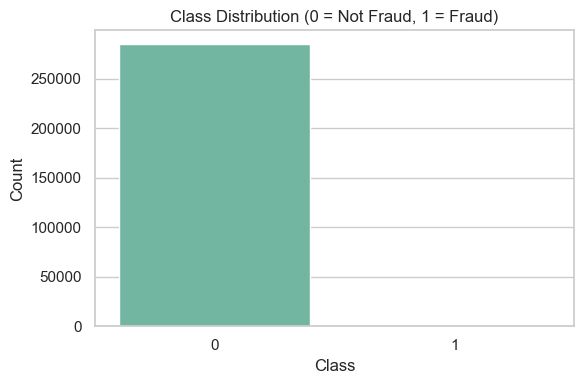

In [5]:
# Countplot of target class
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Class', palette='Set2', hue='Class', legend=False)
plt.title('Class Distribution (0 = Not Fraud, 1 = Fraud)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

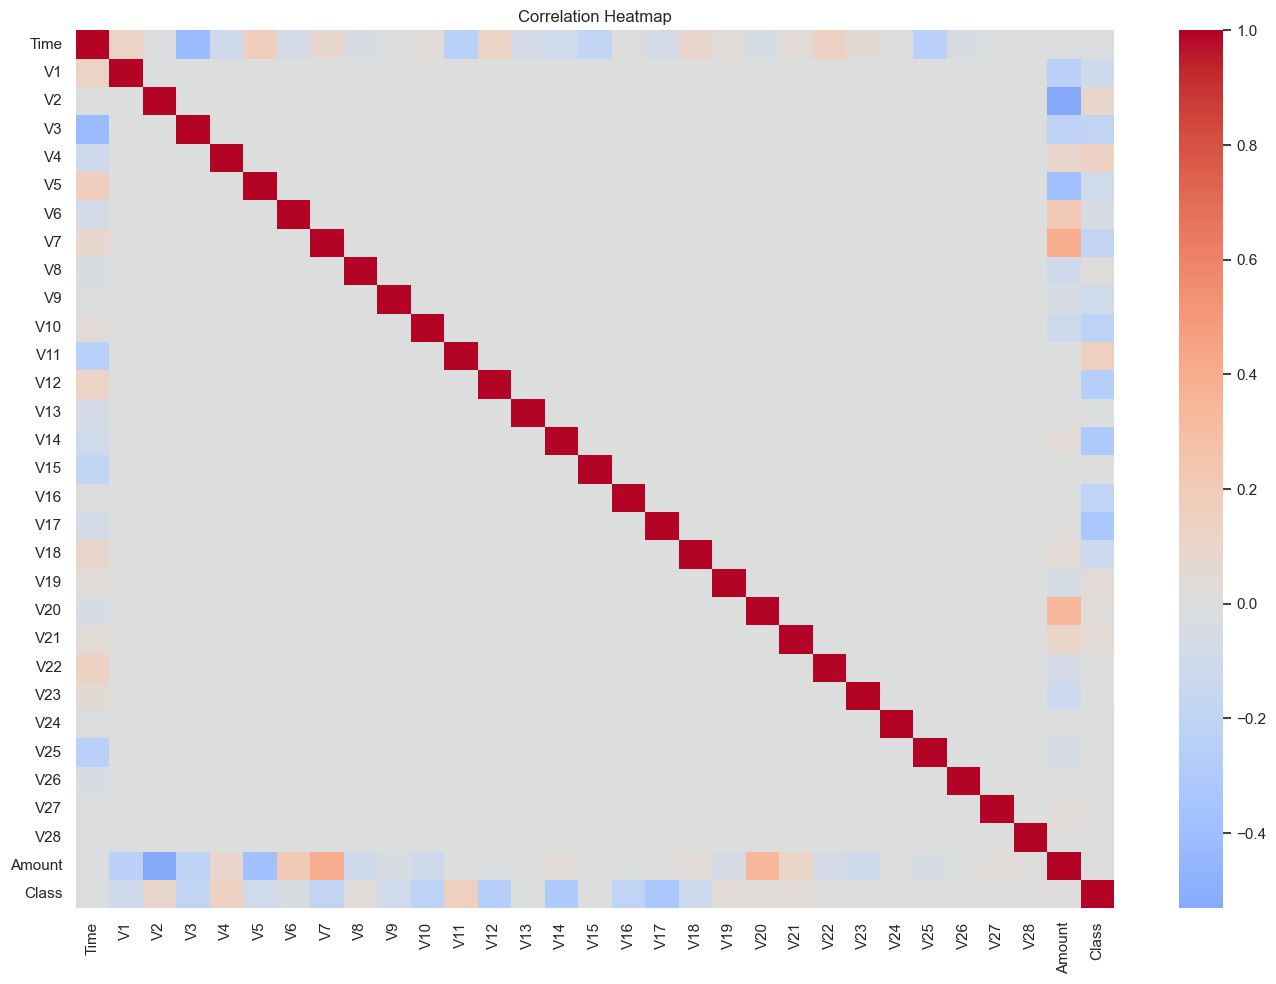

In [6]:
# Correlation heatmap
plt.figure(figsize=(14, 10))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

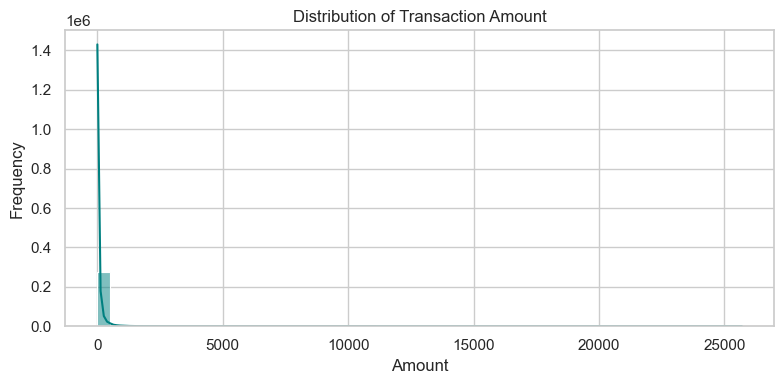

In [7]:
# Distribution of transaction amount
plt.figure(figsize=(8, 4))
sns.histplot(df['Amount'], bins=50, kde=True, color='teal')
plt.title('Distribution of Transaction Amount')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

Steps:
- Normalize `Amount` using `StandardScaler`
- Drop `Time` column (optional, done here)
- Separate features and target

In [8]:
# Keep a copy for reference
data = df.copy()

# Store original input feature order for prediction function
original_feature_columns = [col for col in data.columns if col != 'Class']

# Scale Amount
amount_scaler = StandardScaler()
data['Amount_Scaled'] = amount_scaler.fit_transform(data[['Amount']])

# Drop raw Amount and optionally Time
data = data.drop(columns=['Amount'])
if 'Time' in data.columns:
    data = data.drop(columns=['Time'])

# Separate features and target
X = data.drop(columns=['Class'])
y = data['Class']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (284807, 29)
Target shape: (284807,)


## 5. Train-Test Split and Handle Class Imbalance

We split first, then apply SMOTE only on training data to avoid data leakage.

In [9]:
# 80/20 split with stratification to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTE on training data for all models
smote = SMOTE(random_state=42, sampling_strategy=0.3)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Original training distribution:")
print(y_train.value_counts())
print("\nSMOTE training distribution:")
print(pd.Series(y_train_smote).value_counts())


Original training distribution:
Class
0    227451
1       394
Name: count, dtype: int64

SMOTE training distribution:
Class
0    227451
1     68235
Name: count, dtype: int64


## 6. Model Training

Models trained:
1. Artificial Neural Network (ANN)
2. Support Vector Machine (SVM)
3. K-Nearest Neighbors (KNN)

In [10]:
# ── 1. ANN ──────────────────────────────────────────────────────────────
ann_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_smote.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("Training ANN...")
ann_history = ann_model.fit(
    X_train_smote, y_train_smote,
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
print("ANN training complete.")


C:\Users\ruthv\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training ANN...
Epoch 1/50
1040/1040 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9756 - loss: 0.0757 - val_accuracy: 0.9671 - val_loss: 0.0879
Epoch 2/50
1040/1040 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9886 - loss: 0.0310 - val_accuracy: 0.9833 - val_loss: 0.0453
Epoch 3/50
1040/1040 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9924 - loss: 0.0206 - val_accuracy: 0.9905 - val_loss: 0.0315
Epoch 4/50
1040/1040 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9943 - loss: 0.0162 - val_accuracy: 0.9992 - val_loss: 0.0112
Epoch 5/50
1040/1040 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9956 - loss: 0.0130 - val_accuracy: 0.9999 - val_loss: 0.0075
Epoch 6/50
1040/1040 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9960 - loss: 0.0118 - val_accuracy: 0.9984 - val_loss: 0.0116
Epoch 7/50
1040/1040 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9968 - loss: 0.0099 - val_accuracy: 0.9984 - val_loss: 0.0102
Epoch 8/50
1040/1040 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9968 -

In [11]:
# ── 2. SVM ──────────────────────────────────────────────────────────────
# Using RBF kernel with class_weight='balanced' for imbalanced data
print("Training SVM (this may take a minute)...")
svm_clf = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced',
    probability=True,   # needed for ROC-AUC
    random_state=42
)
svm_clf.fit(X_train_smote, y_train_smote)
print("SVM training complete.")


Training SVM (this may take a minute)...
SVM training complete.


In [12]:
# ── 3. KNN ──────────────────────────────────────────────────────────────
print("Training KNN...")
knn_clf = KNeighborsClassifier(
    n_neighbors=7,
    metric='euclidean',
    n_jobs=-1
)
knn_clf.fit(X_train_smote, y_train_smote)
print("KNN training complete.")


Training KNN...
KNN training complete.


## 7. Model Evaluation

For each model, we calculate:
- Confusion Matrix
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

We also plot ROC curves.

In [13]:
def evaluate_model(model, X_test, y_test, model_name, is_ann=False):
    """Evaluate a classifier and return metrics."""
    if is_ann:
        y_proba = model.predict(X_test).ravel()
        y_pred = (y_proba >= 0.5).astype(int)
    else:
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }

    print(f"\n{model_name} Metrics:")
    for k, v in metrics.items():
        if k != 'Model':
            print(f"{k}: {v:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Fraud', 'Fraud'])
    disp.plot(cmap='Blues')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.grid(False)
    plt.show()

    # ROC curve values
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    return metrics, fpr, tpr


1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 628us/step

ANN Metrics:
Accuracy: 0.9987
Precision: 0.5804
Recall: 0.8469
F1-Score: 0.6888
ROC-AUC: 0.9832


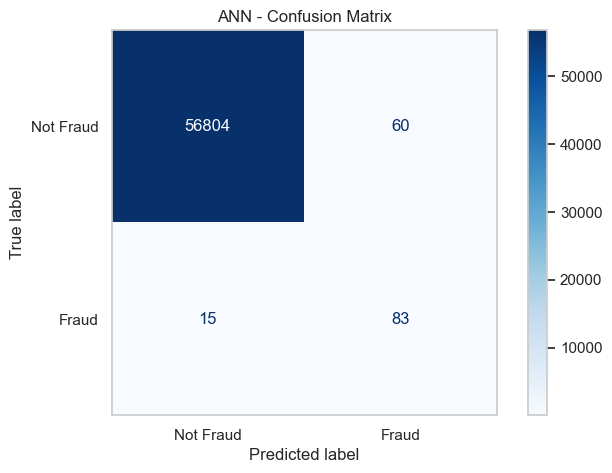


SVM Metrics:
Accuracy: 0.9849
Precision: 0.0894
Recall: 0.8469
F1-Score: 0.1618
ROC-AUC: 0.9739


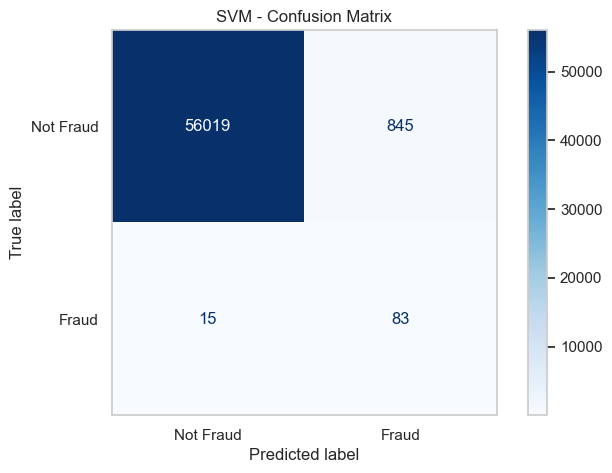


KNN Metrics:
Accuracy: 0.9975
Precision: 0.3982
Recall: 0.8980
F1-Score: 0.5517
ROC-AUC: 0.9484


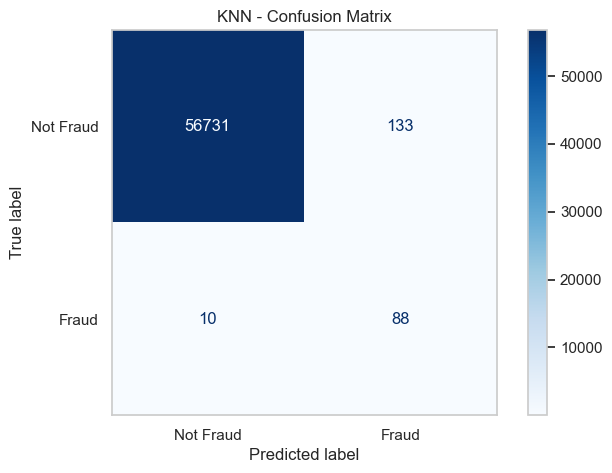

In [14]:
# Evaluate all three models
ann_metrics, ann_fpr, ann_tpr = evaluate_model(ann_model, X_test, y_test, 'ANN', is_ann=True)
svm_metrics, svm_fpr, svm_tpr = evaluate_model(svm_clf, X_test, y_test, 'SVM')
knn_metrics, knn_fpr, knn_tpr = evaluate_model(knn_clf, X_test, y_test, 'KNN')


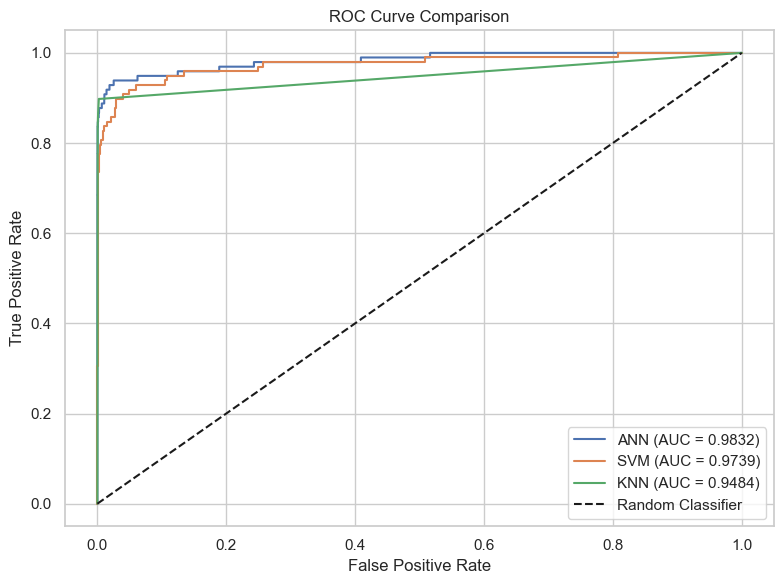

In [15]:
# Plot ROC curves for all three models
plt.figure(figsize=(8, 6))
plt.plot(ann_fpr, ann_tpr, label=f"ANN (AUC = {ann_metrics['ROC-AUC']:.4f})")
plt.plot(svm_fpr, svm_tpr, label=f"SVM (AUC = {svm_metrics['ROC-AUC']:.4f})")
plt.plot(knn_fpr, knn_tpr, label=f"KNN (AUC = {knn_metrics['ROC-AUC']:.4f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()


## 8. Model Comparison

The best model is selected based on **Recall** first, then **F1-Score**.

In [16]:
comparison_df = pd.DataFrame([ann_metrics, svm_metrics, knn_metrics])
comparison_df = comparison_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']]
comparison_df = comparison_df.sort_values(by=['Recall', 'F1-Score'], ascending=False).reset_index(drop=True)

best_model_name = comparison_df.loc[0, 'Model']

model_map = {'ANN': ann_model, 'SVM': svm_clf, 'KNN': knn_clf}
best_model = model_map[best_model_name]
is_best_ann = (best_model_name == 'ANN')

print("Model Comparison Table:")
display(comparison_df.style.highlight_max(subset=['Recall', 'F1-Score'], color='lightgreen'))
print(f"\nBest model based on Recall and F1-Score: {best_model_name}")


Model Comparison Table:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,KNN,0.997490,0.398190,0.897959,0.551724,0.948440
1,ANN,0.998683,0.580420,0.846939,0.688797,0.983221
2,SVM,0.984902,0.089440,0.846939,0.161793,0.973879



Best model based on Recall and F1-Score: KNN


## 9. Save the Best Model

In [17]:
# Save model artifacts needed for future inference
if is_best_ann:
    ann_model.save('fraud_ann_model.keras')
    model_artifacts = {
        'model_type': 'ANN',
        'model_path': 'fraud_ann_model.keras',
        'amount_scaler': amount_scaler,
        'model_feature_columns': X.columns.tolist(),
        'original_feature_columns': original_feature_columns
    }
else:
    model_artifacts = {
        'model_type': best_model_name,
        'model': best_model,
        'amount_scaler': amount_scaler,
        'model_feature_columns': X.columns.tolist(),
        'original_feature_columns': original_feature_columns
    }

joblib.dump(model_artifacts, 'fraud_model.pkl')
print(f"Best model ({best_model_name}) saved.")


Best model (KNN) saved.


## 10. Prediction Function

`predict_transaction(input_data)` accepts one transaction and returns:
- `Fraud`
- `Not Fraud`

In [18]:
def predict_transaction(input_data):
    """
    Predict fraud for a single transaction.

    Parameters
    ----------
    input_data : dict, list, np.ndarray, or pd.Series
        A single transaction with original input features
        (all columns except 'Class').

    Returns
    -------
    str
        'Fraud' or 'Not Fraud'
    """
    # Convert input to one-row DataFrame
    if isinstance(input_data, dict):
        tx = pd.DataFrame([input_data])
    elif isinstance(input_data, pd.Series):
        tx = input_data.to_frame().T
    elif isinstance(input_data, (list, np.ndarray)):
        tx = pd.DataFrame([input_data], columns=model_artifacts['original_feature_columns'])
    else:
        raise TypeError('input_data must be dict, list, np.ndarray, or pd.Series.')

    # Ensure all expected original columns are present
    missing_cols = set(model_artifacts['original_feature_columns']) - set(tx.columns)
    if missing_cols:
        raise ValueError(f'Missing required columns: {sorted(missing_cols)}')

    tx = tx[model_artifacts['original_feature_columns']].copy()

    # Apply the same preprocessing used during training
    tx['Amount_Scaled'] = model_artifacts['amount_scaler'].transform(tx[['Amount']])
    tx = tx.drop(columns=['Amount'])
    if 'Time' in tx.columns:
        tx = tx.drop(columns=['Time'])

    tx = tx[model_artifacts['model_feature_columns']]

    # Predict class
    if model_artifacts.get('model_type') == 'ANN':
        import tensorflow as tf
        loaded_ann = tf.keras.models.load_model(model_artifacts['model_path'])
        proba = loaded_ann.predict(tx)[0][0]
        pred = 1 if proba >= 0.5 else 0
    else:
        pred = model_artifacts['model'].predict(tx)[0]

    return 'Fraud' if pred == 1 else 'Not Fraud'


In [19]:
# Example usage with one row from the original dataset (excluding target)
sample_transaction = df.drop(columns=['Class']).iloc[0]
prediction = predict_transaction(sample_transaction)
print(f"Sample transaction prediction: {prediction}")

Sample transaction prediction: Not Fraud


## 11. Conclusion

This project developed an autonomous fraud detection workflow using machine learning.

Key takeaways:
- The dataset is highly imbalanced, so SMOTE was applied on training data.
- Three models were trained and evaluated: **ANN**, **SVM**, and **KNN**.
- The best model was selected using Recall and F1-score, which are critical for fraud detection tasks.
- **ANN** leverages deep learning for complex pattern recognition in high-dimensional data.
- **SVM** with an RBF kernel excels at finding the optimal decision boundary in transformed feature space.
- **KNN** provides a simple yet effective distance-based classification approach.

In fraud detection, **high recall is especially important** because missing a fraudulent transaction (false negative) can lead to direct financial loss and security risk.